#1. Introdução

##**1.1 Contexto do Problema**
A Telecom X enfrenta um alto índice de cancelamento de clientes, conhecido como Churn (evasão). A evasão ocorre quando um cliente decide encerrar seu contrato com a empresa, impactando diretamente a receita, os custos de aquisição e a sustentabilidade do negócio.

Reter clientes é, geralmente, mais barato do que conquistar novos. Portanto, compreender os fatores que influenciam o cancelamento é essencial para o desenvolvimento de estratégias eficazes de retenção.

##**1.2 Objetivo da Análise**
O objetivo deste projeto é realizar uma análise exploratória dos dados de clientes da Telecom X para:

* Identificar padrões associados à evasão

* Entender o perfil dos clientes que mais cancelam

* Avaliar o impacto de variáveis demográficas, contratuais e financeiras no churn

* Gerar insights que apoiem futuras modelagens preditivas

A partir dessa análise, a equipe de Data Science poderá desenvolver modelos preditivos e estratégias para reduzir o índice de cancelamento.

##**1.3 Base de Dados**
O conjunto de dados analisado contém informações como:

* Perfil do cliente (gênero, idade, parceiro, dependentes)

* Tipo de contrato

* Serviços contratados

* Tempo de permanência (tenure)

* Gastos mensais e totais

* Status de cancelamento (Churn)

Essas variáveis permitem analisar tanto fatores comportamentais quanto financeiros relacionados à evasão.

#2. Importando Dataset

##**2.1 Importação e Estruturação dos Dados**
Os dados foram inicialmente importados para o ambiente Python utilizando a biblioteca Pandas. Como a fonte original estava em formato JSON estruturado, foi utilizada a função pd.json_normalize() para transformar os dados em um formato tabular (DataFrame), facilitando a manipulação e análise.

Esse processo permitiu organizar corretamente as colunas e garantir que cada variável estivesse acessível de forma estruturada.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_json('TelecomX_Data.json')
for coluna in df.columns[2:]:
   df = df.drop(columns=[coluna]).join(pd.json_normalize(df[coluna]))

##**2.2 Tratando as Inconsistências**
Após a importação, foi realizada uma etapa de verificação da qualidade dos dados, com foco em:

* Identificação de valores nulos (NaN)

* Remoção de linhas incompletas

* Correção de inconsistências nos tipos de dados

* Padronização de variáveis categóricas (ex: “Yes” / “No”)

Linhas com dados ausentes ou inconsistentes foram removidas para garantir maior confiabilidade nas análises subsequentes.

Além disso, foi feita a conversão adequada dos tipos das colunas numéricas, como:

* tenure

* Charges.Monthly

* Charges.Total

Isso assegurou que cálculos estatísticos pudessem ser realizados corretamente.

In [4]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df = df.dropna()

df = df[df['Churn'].str.strip() != '']
df['MultipleLines'] = df['MultipleLines'].str.replace(r"^No.*", "No", regex=True)
for coluna in df.columns[10:16]:
  df[coluna] = df[coluna].str.replace(r"^No.*", "No", regex=True)

##**2.3 Criação de Nova Variável: Contas_Diarias**
Para enriquecer a análise financeira e permitir uma visão mais detalhada do comportamento dos clientes, foi criada uma nova variável chamada Contas_Diarias.

Essa coluna representa o gasto médio diário do cliente, calculado a partir do valor mensal:

Contas_Diarias = Charges.Monthly  / 30

Essa métrica auxilia na comparação proporcional entre clientes com diferentes tempos de contrato e facilita análises mais refinadas sobre comportamento de consumo.

In [5]:
df['Contas_Diarias'] = df['Charges.Monthly'] / 30

#3. Análise Exploratória de Dados


##**3.1 Análise Descritiva das Variáveis Numéricas**
A tabela apresentada resume as principais estatísticas descritivas das variáveis numéricas do conjunto de dados, segmentadas pelo status de Churn (clientes que cancelaram e clientes que não cancelaram).

Foram calculadas três métricas principais:

* Média (mean) → Valor médio da variável

* Mediana (median) → Valor central da distribuição

* Desvio padrão (std) → Medida de dispersão dos dados

As variáveis analisadas foram:

* tenure (tempo de contrato em meses)

* Charges.Monthly (valor mensal pago pelo cliente)

* Charges.Total (valor total acumulado pago pelo cliente)

* Contas_Diarias (gasto médio diário)

A segmentação por Churn permite comparar o comportamento financeiro e contratual entre clientes que permaneceram e aqueles que cancelaram.

In [8]:
analise_geral = df.groupby("Churn")[["tenure", "Charges.Monthly", "Charges.Total", "Contas_Diarias"]].agg(["mean", "median", "std"])
analise_geral

tenure                   Charges.Monthly                    \
            mean median        std            mean median        std   
Churn                                                                  
No     37.650010   38.0  24.076940       61.307408  64.45  31.094557   
Yes    17.979133   10.0  19.531123       74.441332  79.65  24.666053   

      Charges.Total                       Contas_Diarias                      
               mean   median          std           mean    median       std  
Churn                                                                         
No      2555.344141  1683.60  2329.456984       2.043580  2.148333  1.036485  
Yes     1531.796094   703.55  1890.822994       2.481378  2.655000  0.822202

###3.1.1 Interpretação dos Resultados


#### 3.1.1.1 Tempo de Contrato (tenure)
Observa-se uma diferença significativa entre os grupos:

* Clientes que não cancelaram possuem média de aproximadamente 37,6 meses de contrato.

* Clientes que cancelaram possuem média de apenas 17,9 meses.

A mediana reforça essa diferença:

* 38 meses para quem permaneceu

* 10 meses para quem cancelou

####3.1.1.2 Gasto Mensal (Charges.Monthly)
Clientes que cancelaram apresentam:

* Média mensal superior (≈ 74,44)

* Mediana também superior (≈ 79,65)

Já os clientes que permaneceram apresentam média menor (≈ 61,31).

####3.1.1.3 Gasto Total (Charges.Total)
O total acumulado é maior para clientes que não cancelaram:

* Média ≈ 2555

* Mediana ≈ 1683

Enquanto clientes que cancelaram acumulam valores menores.

####3.1.1.4 Gasto Médio Diário (Contas_Diarias)
Clientes que cancelaram possuem maior gasto diário médio.

###3.1.2 Principais Conclusões
A análise revela três padrões importantes:

1. O tempo de permanência é um dos fatores mais fortemente associados ao churn.

2. Planos com valores mais altos apresentam maior taxa de cancelamento.

3. A evasão ocorre principalmente nos primeiros meses de contrato.

##**3.2 Análise da Distribuição da Evasão**
Nesta etapa, o objetivo foi entender como a evasão se distribui entre diferentes características dos clientes, como tipo de contrato, serviços contratados e perfil demográfico.

Para isso, foram realizados cálculos percentuais utilizando principalmente value_counts() e pd.crosstab() com normalização por linha.

###3.2.1 Percentual Geral de Cancelamento
O objetivo desse cálculo é medir o tamanho do problema de evasão dentro da base de clientes.

Antes de analisar perfis, contratos ou serviços, é essencial entender:

Qual é a taxa geral de churn da empresa?

Isso fornece uma referência para todas as análises seguintes.

Para identificar a proporção geral de clientes que cancelaram e que permaneceram na base, foi utilizado o seguinte cálculo:

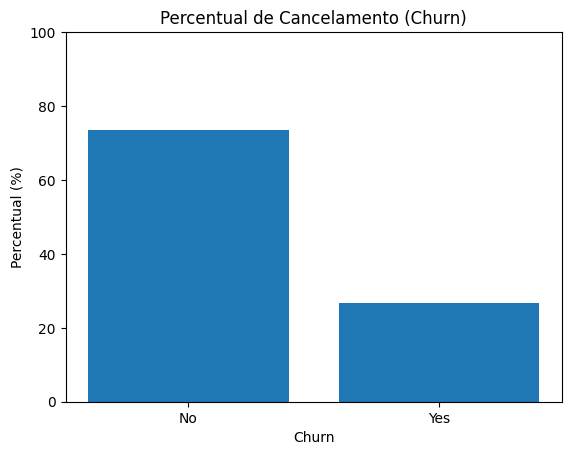

In [13]:
#Cálculo:
percentual_cancelamento = df["Churn"].value_counts(normalize=True) * 100

#Gráfico:
plt.figure()

plt.bar(
    percentual_cancelamento.index,
    percentual_cancelamento.values
)

plt.title("Percentual de Cancelamento (Churn)")
plt.xlabel("Churn")
plt.ylabel("Percentual (%)")

plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

A taxa geral de evasão é de aproximadamente 26,6%.

Isso significa que:

* Cerca de 1 em cada 4 clientes cancela o serviço.

* A maioria dos clientes (73,4%) permanece ativa.

###3.2.2 Percentual de Cancelamento por Contrato
Após analisar a taxa geral de evasão, o próximo passo é verificar se o tipo de contrato influencia a probabilidade de cancelamento.

Clientes podem possuir diferentes tipos de contrato:

* Month-to-month (mensal)

* One year (anual)

* Two year (bienal)

O objetivo dessa análise é identificar se contratos de maior duração estão associados a menor taxa de churn, o que pode indicar maior estabilidade e retenção.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


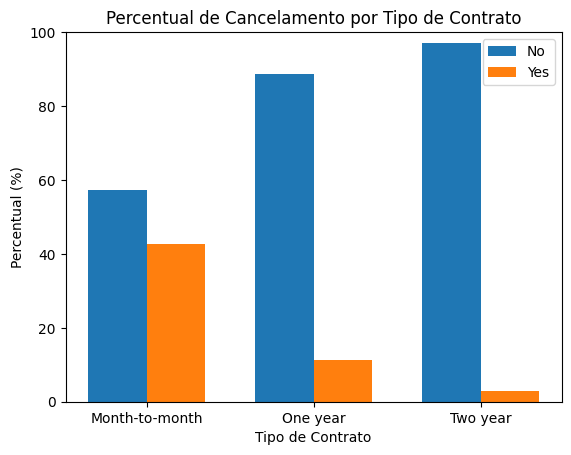

In [17]:
#Cálculo:
cancelamentos_contrato = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

#Gráficos:
x = np.arange(len(cancelamentos_contrato.index))
width = 0.35

plt.figure()

plt.bar(
    x - width/2,
    cancelamentos_contrato["No"],
    width,
    label="No"
)

plt.bar(
    x + width/2,
    cancelamentos_contrato["Yes"],
    width,
    label="Yes"
)

plt.xticks(x, cancelamentos_contrato.index, rotation=0)
plt.ylabel("Percentual (%)")
plt.xlabel("Tipo de Contrato")
plt.title("Percentual de Cancelamento por Tipo de Contrato")
plt.ylim(0, 100)

plt.legend()
plt.show()

A análise revela uma diferença extremamente significativa entre os tipos de contrato.

Principais observações:

* Clientes com contrato mensal (Month-to-month) apresentam taxa de evasão de 42,7%, muito acima da média geral (~26,6%).

* Clientes com contrato de um ano possuem evasão significativamente menor (11,3%).

* Clientes com contrato de dois anos apresentam taxa muito baixa de evasão (2,85%).

###3.2.3 Percentual de Cancelamento por Serviço de Internet
Esta análise busca responder às seguintes questões:

* Clientes com determinados tipos de internet cancelam mais?

* Existe diferença significativa entre tecnologias (DSL vs. Fibra)?

* Clientes que não possuem serviço de internet apresentam menor risco de evasão?

Compreender essa relação permite identificar se algum serviço específico está associado a maior insatisfação ou maior sensibilidade ao preço.

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


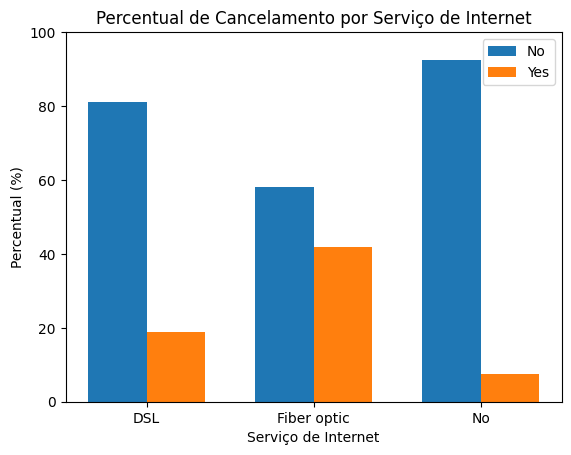

In [18]:
#Cálculo:
cancelamentos_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

#Gráfico:
x = np.arange(len(cancelamentos_internet.index))
width = 0.35

plt.figure()

plt.bar(
    x - width/2,
    cancelamentos_internet["No"],
    width,
    label="No"
)

plt.bar(
    x + width/2,
    cancelamentos_internet["Yes"],
    width,
    label="Yes"
)

plt.xticks(x, cancelamentos_internet.index, rotation=0)
plt.ylabel("Percentual (%)")
plt.xlabel("Serviço de Internet")
plt.title("Percentual de Cancelamento por Serviço de Internet")
plt.ylim(0, 100)

plt.legend()
plt.show()

Os resultados mostram diferenças bastante expressivas entre os tipos de serviço:

* Fiber Optic

  * Apresenta taxa de evasão de 41,89%, muito acima da média geral (~26,6%).

  * É o grupo com maior percentual de cancelamento.

* DSL

  * Taxa de evasão de aproximadamente 19%, abaixo da média geral.

  * Demonstra comportamento mais estável em comparação à fibra.

* Clientes sem Internet

  * Apenas 7,43% de evasão.

  * Representam o grupo mais estável.

###3.2.4 Percentual de Cancelamento por Serviço Variados
O objetivo desta etapa é avaliar se a contratação de serviços adicionais influencia a probabilidade de cancelamento.

A empresa oferece diversos serviços complementares, como:

* Segurança online

* Backup

* Proteção de dispositivos

* Suporte técnico

* Streaming

A pergunta central é:

Clientes que contratam determinados serviços têm menor risco de evasão?

Essa análise é estratégica porque permite identificar serviços que:

* Funcionam como fator de retenção

* Estão associados a maior estabilidade do cliente

* Podem aumentar o valor percebido da empresa

Para evitar repetição de código, foi criada uma função que:

1. Percorre uma lista de colunas

2. Calcula o percentual de churn dentro de cada serviço

3. Retorna um DataFrame consolidado

In [22]:
#Função auxiliar:
def calcular_cancelamentos_colunas(colunas):
  resultados = []
  for coluna in colunas:
    tabela = pd.crosstab(df[coluna], df["Churn"], normalize="index") * 100

    if "Yes" in tabela.index:
      linha = tabela.loc["Yes"]
      linha.name = coluna
      resultados.append(linha)

  return pd.DataFrame(resultados)

Churn                    No        Yes
PhoneService      73.252519  26.747481
MultipleLines     71.351534  28.648466
OnlineSecurity    85.359801  14.640199
OnlineBackup      78.432990  21.567010
DeviceProtection  77.460711  22.539289
TechSupport       84.803922  15.196078
StreamingTV       69.885313  30.114687
StreamingMovies   70.047602  29.952398


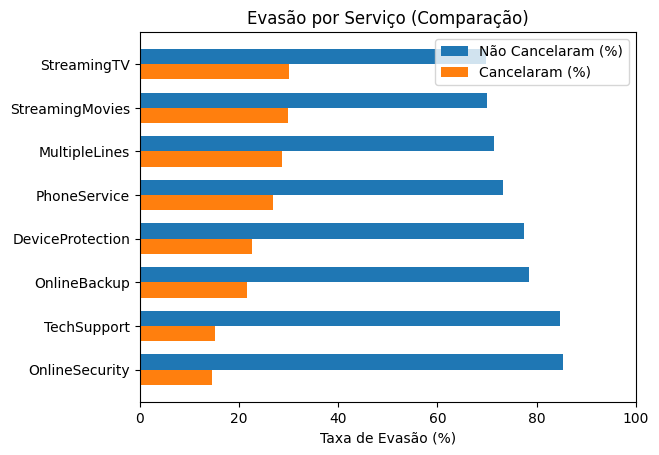

In [23]:
#Calculo:
servicos = df.columns[7:9].append(df.columns[10:16])
cancelamentos_servicos = calcular_cancelamentos_colunas(servicos)

#Gráfico:
cancelamentos_servicos_sorted = cancelamentos_servicos.sort_values(by="Yes", ascending=False)

x = np.arange(len(cancelamentos_servicos_sorted.index))
width = 0.35

plt.figure()

plt.barh(
    x - width/2,
    cancelamentos_servicos_sorted["No"],
    width,
    label="Não Cancelaram (%)"
)

plt.barh(
    x + width/2,
    cancelamentos_servicos_sorted["Yes"],
    width,
    label="Cancelaram (%)"
)

plt.yticks(x, cancelamentos_servicos_sorted.index)
plt.xlabel("Percentual (%)")
plt.title("Evasão por Serviço (Comparação)")
plt.xlim(0, 100)

plt.legend()
plt.gca().invert_yaxis()

plt.show()

A análise revela padrões bastante interessantes.

* Serviços com MAIOR taxa de evasão

  * StreamingTV (~30%)

  * StreamingMovies (~30%)

  * MultipleLines (~28,6%)

Esses serviços apresentam evasão acima ou próximo da média geral (~26,6%).

Isso pode indicar que:

  * Não são fortes fatores de retenção.

  * São percebidos como complementares e não essenciais.

  * Podem estar associados a planos mais caros.

* Serviços com MENOR taxa de evasão

  * OnlineSecurity (~14,6%)

  * TechSupport (~15,2%)

  * OnlineBackup (~21,6%)

Esses serviços apresentam churn significativamente abaixo da média.

Isso sugere que:

* Serviços relacionados a suporte e segurança aumentam o valor percebido.

* Clientes que dependem mais da infraestrutura da empresa tendem a permanecer.

###3.2.5 Percentual de Cancelamento por Perfil do Cliente
Nesta etapa, o objetivo é investigar se características do perfil do cliente influenciam a probabilidade de cancelamento.

Foram analisadas as seguintes variáveis:

* SeniorCitizen (cliente idoso ou não)

* Partner (possui parceiro(a) ou não)

* Dependents (possui dependentes ou não)

Essa análise busca responder:

* Clientes idosos cancelam mais?

* Ter parceiro(a) reduz a probabilidade de evasão?

* Clientes com dependentes são mais estáveis?

Compreender esses padrões permite segmentar estratégias de retenção com base no perfil demográfico.

Churn                 No        Yes
SeniorCitizen  58.318739  41.681261
Partner        80.282935  19.717065
Dependents     84.468795  15.531205


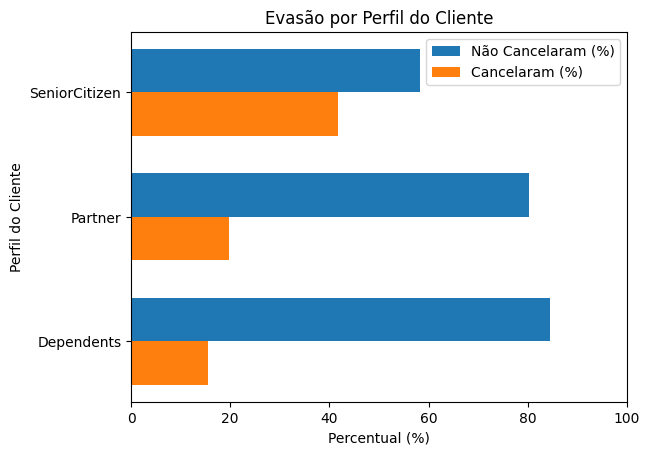

In [28]:
#Cálculo
perfis = df.columns[3:6]
cancelamentos_perfis = calcular_cancelamentos_colunas(perfis)
print(cancelamentos_perfis)
#Gráfico
cancelamentos_perfis_sorted = cancelamentos_perfis.sort_values(by="Yes", ascending=False)

x = np.arange(len(cancelamentos_perfis_sorted.index))
width = 0.35

plt.figure()

plt.barh(
    x - width/2,
    cancelamentos_perfis_sorted["No"],
    width,
    label="Não Cancelaram (%)"
)

plt.barh(
    x + width/2,
    cancelamentos_perfis_sorted["Yes"],
    width,
    label="Cancelaram (%)"
)

plt.yticks(x, cancelamentos_perfis_sorted.index)
plt.xlabel("Percentual (%)")
plt.ylabel("Perfil do Cliente")
plt.title("Evasão por Perfil do Cliente")
plt.xlim(0, 100)

plt.legend()
plt.gca().invert_yaxis()

plt.show()

Os resultados mostram diferenças importantes entre os perfis analisados.

* SeniorCitizen

  * Taxa de evasão de 41,68%

  * Bem acima da média geral (~26,6%)

* Partner

  * Taxa de evasão de 19,72%

  * Abaixo da média geral

  * Clientes com parceiro(a) tendem a permanecer mais tempo na empresa.

* Dependents

  * Taxa de evasão de 15,53%

  * Uma das menores taxas observadas

  * Clientes com dependentes demonstram maior estabilidade contratual.

###3.2.6 Distribuição de Cancelamento por Total Gasto

O objetivo desta etapa é analisar como o total gasto acumulado (Charges.Total) se distribui entre clientes que cancelaram e clientes que permaneceram na base.

Diferentemente das análises anteriores, aqui não estamos calculando percentuais, mas observando a distribuição completa dos valores, incluindo:

* Mediana

* Intervalo interquartil (Q1 – Q3)

* Dispersão

* Valores extremos (outliers)

Essa análise permite entender se existe diferença relevante no comportamento financeiro entre os grupos.

<Figure size 640x480 with 0 Axes>

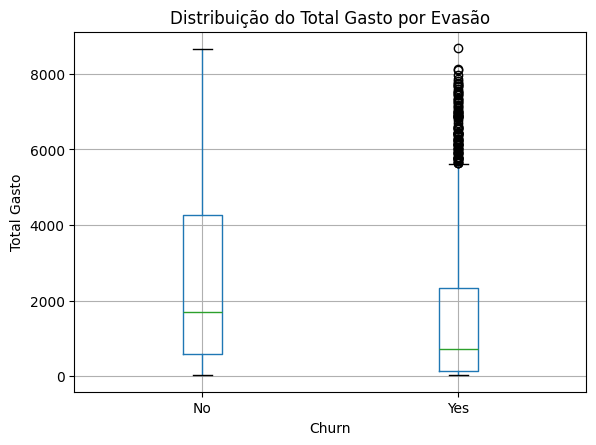

In [29]:
#Gráfico:
plt.figure()
df.boxplot(column="Charges.Total", by="Churn")
plt.title("Distribuição do Total Gasto por Evasão")
plt.suptitle("")
plt.ylabel("Total Gasto")
plt.show()

O gráfico mostra diferenças claras entre os dois grupos.

* Mediana

  * A mediana do Total Gasto é significativamente maior para clientes que não cancelaram.

  * Clientes que cancelaram apresentam mediana bem inferior.

Isso indica que clientes que permanecem acumulam naturalmente mais valor ao longo do tempo.

* Dispersão

  * O grupo "No" (não cancelaram) apresenta maior amplitude de valores.

  * O grupo "Yes" possui maior concentração em valores baixos.

Isso reforça que muitos cancelamentos ocorrem quando o cliente ainda acumulou pouco gasto total — ou seja, cancelamentos tendem a acontecer relativamente cedo.

* Outliers

  * No grupo que cancelou, observam-se alguns valores altos (outliers).

Isso indica que mesmo clientes com alto gasto acumulado podem cancelar e que o total gasto não é o único fator determinante da permanência.

#4. Conclusões e Insights
A análise exploratória dos dados permitiu identificar padrões consistentes associados à evasão de clientes (Churn) na Telecom X. Os principais achados indicam que o cancelamento não ocorre de forma aleatória, mas está fortemente relacionado a fatores contratuais, financeiros e comportamentais.

##**4.1 Tempo de Permanência**
O tempo de contrato (tenure) mostrou-se um dos fatores mais fortemente associados ao churn. Clientes que cancelam permanecem, em média, menos da metade do tempo em comparação aos que continuam ativos.

Além disso, a mediana de apenas 10 meses para clientes que cancelaram indica que a evasão ocorre majoritariamente nos primeiros meses de contrato.

**Insight**:
A fase inicial da jornada do cliente é crítica. Estratégias de retenção devem focar especialmente nos primeiros meses.

##**4.2 Planos Mais Caros**
Clientes que cancelaram possuem, em média, maior gasto mensal e diário. Isso sugere possível sensibilidade ao preço ou percepção de custo-benefício insuficiente.

O serviço de fibra óptica, por exemplo, apresentou taxa de evasão significativamente superior às demais modalidades de internet.

**Insight**:
Planos premium precisam reforçar a percepção de valor entregue ao cliente.

##**4.3 Tipo de Contrato**
Clientes com contrato mensal apresentaram taxa de evasão extremamente superior aos contratos anuais e bienais.

Contratos mais longos mostraram forte efeito de retenção.

**Insight**:
Incentivar migração para contratos de maior duração pode reduzir significativamente a evasão.

##**4.4 Serviços**
Serviços como:

* Online Security

* Tech Support

* Online Backup

apresentaram taxas de evasão consideravelmente menores.

Já serviços de entretenimento (Streaming) demonstraram impacto reduzido na retenção.

**Insight**:
Serviços que aumentam a dependência funcional do cliente tendem a reduzir o cancelamento.

##**4.5 Perfil do Cliente**
Clientes com parceiro(a) e dependentes apresentam taxas de churn significativamente menores, indicando maior estabilidade contratual.

Por outro lado, clientes idosos demonstraram maior taxa de evasão.

**Insight**:
Segmentações demográficas podem ser utilizadas para estratégias preventivas mais direcionadas.

##**4.6 Como Esses Dados Podem Ajudar a Reduzir a Evasão**

A partir desses achados, a empresa pode:

* Identificar clientes com maior risco nos primeiros meses

* Incentivar contratos de maior duração

* Melhorar a percepção de valor dos planos premium

* Oferecer pacotes com serviços de suporte e segurança

* Criar campanhas segmentadas por perfil

Essas ações podem contribuir diretamente para:

* Aumento da retenção

* Crescimento do tempo médio de permanência

* Maior receita recorrente

* Redução dos custos de aquisição de novos clientes

#5. Recomendações Estratégicas
Com base nas análises realizadas, nos padrões identificados e nos insights extraídos, seguem recomendações práticas e direcionadas para reduzir a evasão de clientes e aumentar a retenção.

##**5.1 Foco Estratégico nos Primeiros Meses de Contrato**
Como observado, a evasão é significativamente maior em contratos mensais e nos primeiros meses de relacionamento.

Recomendações:

* Criar um programa de onboarding estruturado para novos clientes.

* Oferecer benefícios progressivos nos primeiros 3–6 meses.

* Implementar acompanhamento ativo (e-mails, mensagens, suporte dedicado).

* Criar incentivos para migração de plano mensal para plano anual.

Objetivo: aumentar o vínculo inicial e reduzir a evasão precoce.

##**5.2 Reavaliar Proposta de Valor dos Serviços Premium**
Serviços como fibra óptica e streaming apresentaram maior taxa de cancelamento, sugerindo possível desequilíbrio entre preço e percepção de valor.

Recomendações:

* Revisar política de preços dos planos premium.

* Criar pacotes com melhor custo-benefício.

* Incluir benefícios adicionais (ex: bônus de velocidade, upgrade temporário).

* Melhorar comunicação do diferencial competitivo desses serviços.

Objetivo: aumentar percepção de valor e reduzir cancelamentos por insatisfação financeira.

##**5.3 Estratégia Focada no Público Jovem**
Os dados sugerem menor retenção em perfis sem parceiro(a) ou dependentes — possivelmente jovens adultos, que também são grandes consumidores de internet.

Recomendações:

* Criar planos mais acessíveis para o público jovem.

* Oferecer combos flexíveis e personalizáveis.

* Investir em benefícios digitais (ex: bônus para jogos, redes sociais).

* Desenvolver campanhas voltadas para estudantes e jovens profissionais.

Objetivo: alinhar preço e proposta de valor ao poder aquisitivo e às necessidades desse público.

##**5.4 Explorar Pontos Fortes: Serviços de Segurança e Suporte**
Serviços como segurança online e suporte técnico mostraram maior associação com retenção.

Recomendações:

* Incluir serviços de segurança como diferencial competitivo.

* Criar bundles com suporte premium incluso.

* Comunicar mais claramente os benefícios desses serviços.

Objetivo: aumentar a dependência funcional do cliente, reduzindo a probabilidade de cancelamento.

##**5.5 Estratégia de Segmentação e Retenção Preditiva**
Os dados permitem identificar perfis de maior risco de evasão.

Recomendações:

* Desenvolver modelo preditivo de evasão.

* Criar campanhas específicas para clientes com:

  * Baixo tempo de contrato

  * Plano mensal

  * Alto valor mensal

* Oferecer ofertas personalizadas antes do cancelamento.

Objetivo: agir preventivamente, não reativamente.

##**5.6 Direcionamento Estratégico Final**

A TelecomX possui duas alternativas estratégicas claras:

* **Estratégia 1 – Ajuste Competitivo**

Reduzir preços e melhorar proposta de valor dos serviços modernos para aumentar retenção no público jovem e sensível a preço.

* **Estratégia 2 – Consolidação de Diferenciais**

Fortalecer os serviços que geram maior retenção (segurança, suporte) e posicionar-se como empresa de maior qualidade e confiabilidade.

Idealmente, a empresa pode adotar uma abordagem híbrida:

  * Competitividade nos planos de entrada.

  * Diferenciação nos planos premium.